## 1. Load manifest

In [1]:
from pathlib import Path

ROOT = Path("..")
MANIFEST = ROOT / "data/processed/manifest_pool.csv"

RESULTS_FIG = ROOT / "results/figures"
RESULTS_LOG = ROOT / "results/logs"

RESULTS_FIG.mkdir(parents=True, exist_ok=True)
RESULTS_LOG.mkdir(parents=True, exist_ok=True)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(MANIFEST)
df.head()

,path,filename,samplerate,channels,frames,duration_sec,source_dir
0,data/raw/piano/fur_elise/Fur_elise_1.wav,Fur_elise_1.wav,44100,2,1124550,25.5,data/raw/piano/fur_elise
1,data/raw/piano/fur_elise/Fur_elise_10.wav,Fur_elise_10.wav,44100,2,1124550,25.5,data/raw/piano/fur_elise
2,data/raw/piano/fur_elise/Fur_elise_11.wav,Fur_elise_11.wav,44100,2,1124550,25.5,data/raw/piano/fur_elise
3,data/raw/piano/fur_elise/Fur_elise_12.wav,Fur_elise_12.wav,44100,2,1124550,25.5,data/raw/piano/fur_elise
4,data/raw/piano/fur_elise/Fur_elise_13.wav,Fur_elise_13.wav,44100,2,1124550,25.5,data/raw/piano/fur_elise


## 2. Basic stats

In [3]:

print("files:", len(df))
print("columns:", list(df.columns))
df.describe(include="all")

files: 180
columns: ['path', 'filename', 'samplerate', 'channels', 'frames', 'duration_sec', 'source_dir']


,path,filename,samplerate,channels,frames,duration_sec,source_dir
count,180,180,180.0,180.000000,1.800000e+02,180.000000,180
unique,180,180,NaN,NaN,NaN,NaN,2
top,data/raw/piano/fur_elise/Fur_elise_1.wav,Fur_elise_1.wav,NaN,NaN,NaN,NaN,data/synthetic/piano/fur_elise_aug
freq,1,1,NaN,NaN,NaN,NaN,120
mean,NaN,NaN,44100.0,1.333333,1.132605e+06,25.682660,NaN
std,NaN,NaN,0.0,0.472719,2.749049e+04,0.623367,NaN
min,NaN,NaN,44100.0,1.000000,1.072560e+06,24.321088,NaN
25%,NaN,NaN,44100.0,1.000000,1.124550e+06,25.500000,NaN
50%,NaN,NaN,44100.0,1.000000,1.124550e+06,25.500000,NaN
75%,NaN,NaN,44100.0,2.000000,1.151526e+06,26.111712,NaN


In [4]:
dur = df["duration_sec"].astype(float)

stats = {
    "min_sec": float(dur.min()),
    "mean_sec": float(dur.mean()),
    "median_sec": float(dur.median()),
    "max_sec": float(dur.max()),
    "std_sec": float(dur.std()),
}

stats

{'min_sec': 24.32108843537415,
 'mean_sec': 25.682660115898216,
 'median_sec': 25.5,
 'max_sec': 27.69482993197279,
 'std_sec': 0.6233670206220187}

In [5]:
sr_counts = df["samplerate"].value_counts()
ch_counts = df["channels"].value_counts()

sr_counts, ch_counts

(samplerate
 44100    180
 Name: count, dtype: int64,
 channels
 1    120
 2     60
 Name: count, dtype: int64)

## 3. Histograms

NameError: name 'dur_f' is not defined

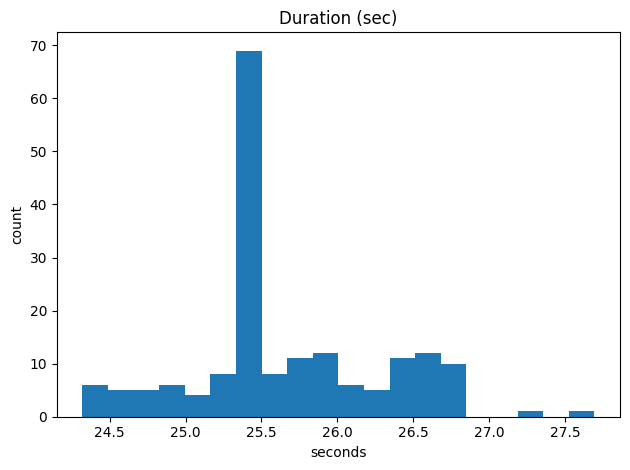

<Figure size 640x480 with 0 Axes>

In [6]:
plt.figure()
plt.hist(dur, bins=20)
plt.title("Duration (sec)")
plt.xlabel("seconds")
plt.ylabel("count")
plt.tight_layout()

out_path_final = RESULTS_FIG / "duration_hist_final.png"
plt.figure()
plt.hist(dur_f, bins=15)
plt.title("Final dataset duration (sec)")
plt.xlabel("seconds")
plt.ylabel("count")
plt.tight_layout()
plt.savefig(out_path_final, dpi=150)
plt.show()

out_path_final

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_final = pd.read_csv(ROOT / "dataset/final/manifest.csv")

dur_f = df_final["duration_sec"].astype(float)

plt.figure()
plt.hist(dur_f, bins=15)
plt.title("Final dataset duration (sec)")
plt.xlabel("seconds")
plt.ylabel("count")
plt.tight_layout()
plt.show()

df_final.head()

In [ ]:
q1, q3 = dur.quantile([0.25, 0.75])
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

out = df[(dur < low) | (dur > high)].copy()
out = out.sort_values("duration_sec")

out[["filename", "duration_sec", "samplerate", "channels"]]

In [ ]:
shortest = df.sort_values("duration_sec").head(10)
longest = df.sort_values("duration_sec").tail(10)

shortest[["filename", "duration_sec"]], longest[["filename", "duration_sec"]]

In [ ]:
import random
import numpy as np
import pandas as pd
import soundfile as sf
from pathlib import Path

paths = df["path"].astype(str).tolist()

existing = []
missing = []

for rel in paths:
    p = ROOT / rel
    if p.exists():
        existing.append(rel)
    else:
        missing.append(rel)

print("existing:", len(existing))
print("missing:", len(missing))

sample_n = min(10, len(existing))
sample_paths = random.sample(existing, k=sample_n)

rows = []
failed = []

for rel in sample_paths:
    p = ROOT / rel
    try:
        y, sr = sf.read(str(p), dtype="float32")
    except Exception:
        failed.append(rel)
        continue

    if y.ndim > 1:
        y = y.mean(axis=1)

    peak = float(np.max(np.abs(y))) if len(y) else 0.0
    rms = float(np.sqrt(np.mean(y**2))) if len(y) else 0.0
    silence_ratio = float(np.mean(np.abs(y) < 1e-3)) if len(y) else 1.0
    clipped = bool(peak >= 0.999)

    rows.append({
        "filename": Path(rel).name,
        "peak": peak,
        "rms": rms,
        "silence_ratio": silence_ratio,
        "clipped": clipped,
    })

print("failed reads:", len(failed))

qc = pd.DataFrame(rows).sort_values(["clipped", "silence_ratio"], ascending=[False, False])
qc

In [ ]:
qc[(qc["clipped"] == True) | (qc["silence_ratio"] > 0.85)]

## 4. Play sounds

In [ ]:
import random
import librosa
from IPython.display import Audio, display

sample_n = min(3, len(existing))
sample_files = random.sample(existing, k=sample_n)

for rel in sample_files:
    p = ROOT / rel
    y, sr = librosa.load(p, sr=None, mono=True, duration=5.0)
    print(p.name, "sr:", sr, "sec:", round(len(y)/sr, 2))
    display(Audio(y, rate=sr))

## 5. Save results

In [ ]:
from pathlib import Path
import json

Path("../results/logs").mkdir(parents=True, exist_ok=True)

summary = {
    "n_files": int(len(df)),
    "samplerates": df["samplerate"].value_counts().to_dict(),
    "channels": df["channels"].value_counts().to_dict(),
    "duration_sec": {k: round(v, 4) for k, v in stats.items()},
}

Path("../results/logs/dataset_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8"
)

summary

In [ ]:
qc_path = ROOT / "data/processed/qc_sample.csv"
if "qc" in globals():
    qc.to_csv(qc_path, index=False)

summary["figures"] = {
    "duration_hist": str(RESULTS_FIG / "duration_hist.png"),
}
summary["qc_sample_csv"] = str(qc_path) if qc_path.exists() else None

(Path(RESULTS_LOG) / "dataset_summary.json").write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8"
)

summary

In [ ]:
from pathlib import Path
import json

FINAL = ROOT / "dataset/final"
AUDIO_DIR = FINAL / "audio"
ANN_DIR = FINAL / "annotations"
PARAMS = FINAL / "parameters.json"

print("final exists:", FINAL.exists())
print("audio files:", len(list(AUDIO_DIR.glob("*.wav"))))
print("annotation files:", len(list(ANN_DIR.glob("*.csv"))))
print("parameters.json:", PARAMS.exists())

In [ ]:
import pandas as pd

wavs = sorted(AUDIO_DIR.glob("*.wav"))
missing = []
bad_header = []

expected_header = ["time_stretch","pitch_shift","loudness_rms","spectral_centroid","source"]

for w in wavs:
    c = ANN_DIR / (w.stem + ".csv")
    if not c.exists():
        missing.append(w.name)
        continue
    header = list(pd.read_csv(c, nrows=0).columns)
    if header != expected_header:
        bad_header.append((c.name, header))

print("missing csv:", len(missing))
print("bad header:", len(bad_header))
missing[:5], bad_header[:5]

In [ ]:
summary["final_dataset"] = {
    "path": str(FINAL),
    "n_audio": len(list(AUDIO_DIR.glob("*.wav"))),
    "n_annotations": len(list(ANN_DIR.glob("*.csv"))),
    "parameters_json": str(PARAMS),
}

In [ ]:
df_final = pd.read_csv(ROOT / "dataset/final/manifest.csv")
df_final[["filename","duration_sec"]].describe()